In [283]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys, os
import glob
import json

In [402]:
def get_summed_arr_and_pid_vals(year):
    """
    Being in the v1 directory, this will pull all of the .npy and _cal_soltions.json files from each years directory

    Input: Year you would like to get .npy and _cal_solutions.json files from
    
    Doing: 
     - Opens npy file and adds all the recorded days of the year
     - Opens .json files and pulls the best recorded kp, ki, kd values 
     
    Output: Summed array
    """
    d_path = '/Users/angeludr/Documents/GitHub/sma_phasing_sims/vlbi_cal/v1'
    npy_file = '*.npy'
    swarm_data = glob.glob(d_path + '/' + str(year) + '/' + npy_file, recursive = True)

    # Used the get just the file name but further down it could not open the file because it did not have the proper directory paths in it
    npy_files = [os.path.basename(f) for f in swarm_data]

    arrays = []
    for data in swarm_data:
        results_arr = np.load(data)
        arrays.append(results_arr)

    summed = 0
    for array in arrays:
        summed = summed + array

    
    # These kp, ki, kd values were just pulled from the original code - no summing, just pulled straight out and into a json file
    kp = []
    ki = []
    kd = []
    
    cal_json = '*_cal_solutions.json'
    cal_files = glob.glob(d_path + '/' + str(year) + '/' + cal_json, recursive = True)

    for files in cal_files:
        cals = open(files)
        cals = json.load(cals)
        
        kp.append(cals['best_cal_solutions']['kp'])
        ki.append(cals['best_cal_solutions']['ki'])
        kd.append(cals['best_cal_solutions']['kd'])
        
    return summed, np.array(kp), np.array(ki), np.array(kd)

In [23]:
def get_best_0th(summed_array):
    """
    Mean metric
    """

    row = summed_array[:,:,:,0,0]
    best_x, best_y, best_z = np.where(row == np.max(row))
    eff = row[best_x, best_y, best_z]
    
    #return best_x[0], best_y[0], best_z[0], eff
    return eff

In [25]:
def get_best_1st(summed_array):
    """
    Mean-squared metric
    """

    row = summed_array[:,:,:,0,1]
    best_x, best_y, best_z = np.where(row == np.max(row))
    eff = row[best_x, best_y, best_z]

    #return best_x, best_y, best_z, eff
    return eff

In [80]:
def get_best_7th(summed_array):
    """
    80% uptime metric
    """

    row = summed_array[:,:,:,0,7]
    best_x, best_y, best_z = np.where(row == np.max(row))
    eff = row[best_x, best_y, best_z]

    #return best_x, best_y, best_z, eff
    return eff

### Getting swarm_data > summed results_arr > best metric values in the 0th, 1st, and 7th metrics

In [374]:
# Best kp, ki, kd values from each recorded day compiled into one list
# Nothing has been done to these values - just picked out and shoved into a json file
d_path = '/Users/angeludr/Documents/GitHub/sma_phasing_sims/vlbi_cal/v1'
cal_json = '*_cal_solutions.json'

# Goes through all directories in vlbi_cal/v1 (each year) and gets all recorded kp, ki, kd
all_cal_files = glob.glob(d_path + '/**/' + cal_json, recursive = True)

all_kp = []
all_ki = []
all_kd = []

for files in all_cal_files:
    cals = open(files)
    cals = json.load(cals)

    all_kp.append(cals['best_cal_solutions']['kp'])
    all_ki.append(cals['best_cal_solutions']['ki'])
    all_kd.append(cals['best_cal_solutions']['kd'])

summed_kp = 0
for val in all_kp:
    summed_kp = summed_kp + val

summed_ki = 0
for val in all_ki:
    summed_ki = summed_ki + val

summed_kd = 0
for val in all_kd:
    summed_kd = summed_kd + val

In [404]:
summed17, kp17, ki17, kd17 = get_summed_arr_and_pid_vals(2017)
summed18, kp18, ki18, kd18 = get_summed_arr_and_pid_vals(2018)
summed20, kp20, ki20, kd20 = get_summed_arr_and_pid_vals(2020)
summed21, kp21, ki21, kd21 = get_summed_arr_and_pid_vals(2021)
summed22, kp22, ki22, kd22 = get_summed_arr_and_pid_vals(2022)
summed23, kp23, ki23, kd23 = get_summed_arr_and_pid_vals(2023)
summed24, kp24, ki24, kd24 = get_summed_arr_and_pid_vals(2024)

In [32]:
eff17_0th = get_best_0th(summed2017)
eff18_0th = get_best_0th(summed2018)
eff20_0th = get_best_0th(summed2020)
eff21_0th = get_best_0th(summed2021)
eff22_0th = get_best_0th(summed2022)
eff23_0th = get_best_0th(summed2023)
eff24_0th = get_best_0th(summed2024)

In [34]:
eff17_1st = get_best_1st(summed2017)
eff18_1st = get_best_1st(summed2018)
eff20_1st = get_best_1st(summed2020)
eff21_1st = get_best_1st(summed2021)
eff22_1st = get_best_1st(summed2022)
eff23_1st = get_best_1st(summed2023)
eff24_1st = get_best_1st(summed2024)

In [25]:
eff17_7th = get_best_7th(summed2017)
eff18_7th = get_best_7th(summed2018)
eff20_7th = get_best_7th(summed2020)
eff21_7th = get_best_7th(summed2021)
eff22_7th = get_best_7th(summed2022)
eff23_7th = get_best_7th(summed2023)
eff24_7th = get_best_7th(summed2024)

### PLOTS (scatter and hist of original data array)

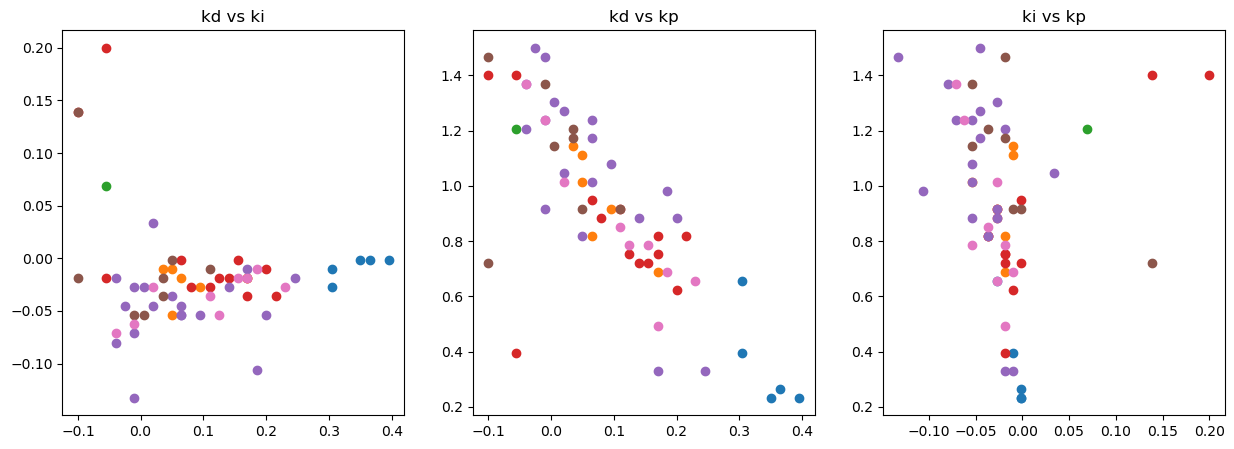

<Figure size 1920x1440 with 0 Axes>

In [406]:
fig = plt.figure(figsize=(15.0, 5.0))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

# kd vs ki
ax1.scatter(kd17, ki17)
ax1.scatter(kd18, ki18)
ax1.scatter(kd20, ki20)
ax1.scatter(kd21, ki21)
ax1.scatter(kd22, ki22)
ax1.scatter(kd23, ki23)
ax1.scatter(kd24, ki24)
ax1.title.set_text('kd vs ki')

# kd vs kp
ax2.scatter(kd17, kp17)
ax2.scatter(kd18, kp18)
ax2.scatter(kd20, kp20)
ax2.scatter(kd21, kp21)
ax2.scatter(kd22, kp22)
ax2.scatter(kd23, kp23)
ax2.scatter(kd24, kp24)
ax2.title.set_text('kd vs kp')

# ki vs kp
ax3.scatter(ki17, kp17)
ax3.scatter(ki18, kp18)
ax3.scatter(ki20, kp20)
ax3.scatter(ki21, kp21)
ax3.scatter(ki22, kp22)
ax3.scatter(ki23, kp23)
ax3.scatter(ki24, kp24)
ax3.title.set_text('ki vs kp')

plt.figure(dpi=300)
plt.savefig('k_pid_scatter.png')

plt.show()

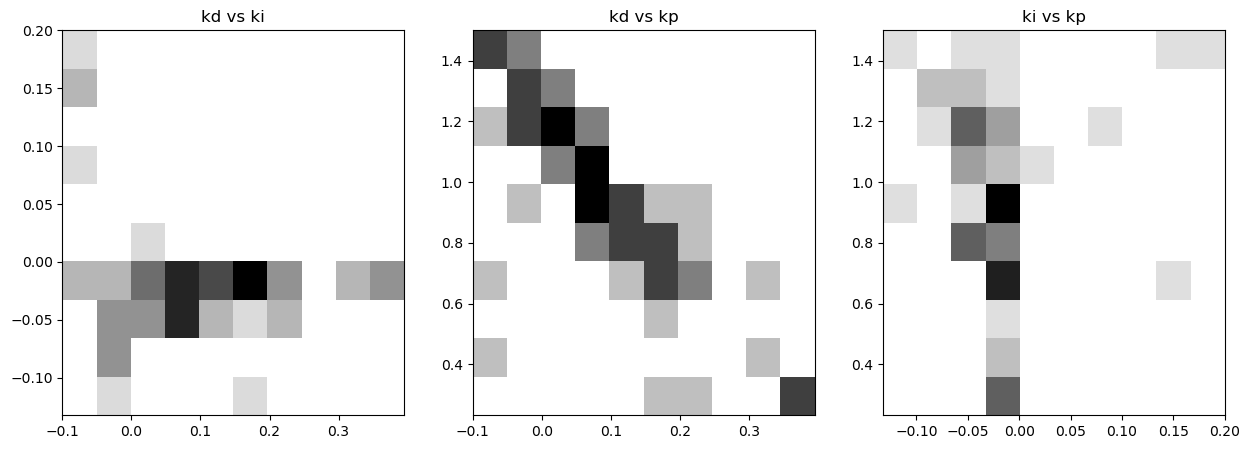

<Figure size 1920x1440 with 0 Axes>

In [408]:
fig = plt.figure(figsize=(15.0, 5.0))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

# kd vs ki
ax1.hist2d(all_kd, all_ki, cmap='binary')
ax1.title.set_text('kd vs ki')

# kd vs kp
ax2.hist2d(all_kd, all_kp, cmap='binary')
ax2.title.set_text('kd vs kp')

# ki vs kp
ax3.hist2d(all_ki, all_kp, cmap='binary')
ax3.title.set_text('ki vs kp')

plt.figure(dpi=300)
plt.savefig('k_pid_hist.png')

plt.show()

####